# AI Customer SupportAgent

## Dataset Exploration

### objective


The goal of this notebook is to:

- Load the dataset
- Understand its structure
- Explore the available columns
- Check for missing values
- Analyze customer intents
- Prepare the dataset for future NLP tasks

This notebook is part of the AI Customer Support Agent project.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


In [4]:
df = pd.read_csv("../data/raw/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv")

In [5]:
df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [10]:
df.shape

(26872, 5)

In [7]:
df.columns

Index(['flags', 'instruction', 'category', 'intent', 'response'], dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   flags        26872 non-null  str  
 1   instruction  26872 non-null  str  
 2   category     26872 non-null  str  
 3   intent       26872 non-null  str  
 4   response     26872 non-null  str  
dtypes: str(5)
memory usage: 19.1 MB


In [9]:
df.describe(include="all")

,flags,instruction,category,intent,response
count,26872,26872,26872,26872,26872
unique,394,24635,11,27,26870
top,BL,do you ship to {{Delivery City}}?,ACCOUNT,check_invoice,"Firstly, I truly understand how pivotal the {{..."
freq,5212,8,5986,1000,2


In [11]:
df.isna().sum()

flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['category'].nunique()

11

In [14]:
sorted(df['category'].unique())

['ACCOUNT',
 'CANCEL',
 'CONTACT',
 'DELIVERY',
 'FEEDBACK',
 'INVOICE',
 'ORDER',
 'PAYMENT',
 'REFUND',
 'SHIPPING',
 'SUBSCRIPTION']

In [15]:
df["intent"].nunique()

27

In [16]:
sorted(df["intent"].unique())[:20]

['cancel_order',
 'change_order',
 'change_shipping_address',
 'check_cancellation_fee',
 'check_invoice',
 'check_payment_methods',
 'check_refund_policy',
 'complaint',
 'contact_customer_service',
 'contact_human_agent',
 'create_account',
 'delete_account',
 'delivery_options',
 'delivery_period',
 'edit_account',
 'get_invoice',
 'get_refund',
 'newsletter_subscription',
 'payment_issue',
 'place_order']

In [17]:
plt.style.use("default")

In [18]:
category_counts = df["category"].value_counts()

category_counts

category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64

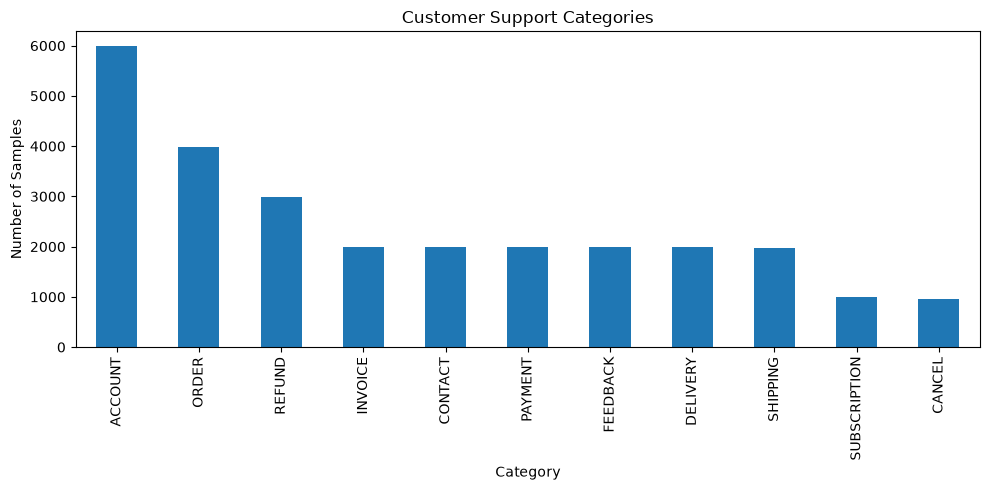

In [19]:
plt.figure(figsize = (10,5))

category_counts.plot(kind = "bar")

plt.title("Customer Support Categories")

plt.xlabel("Category")

plt.ylabel("Number of Samples")

plt.tight_layout()

plt.show()

In [22]:
intent_counts = df["intent"].value_counts()

intent_counts.head(10)

intent
check_invoice               1000
complaint                   1000
contact_customer_service    1000
edit_account                1000
switch_account              1000
check_payment_methods        999
contact_human_agent          999
delivery_period              999
get_invoice                  999
newsletter_subscription      999
Name: count, dtype: int64

# Obeservations

## Dataset summary

- The dataset contains **26,872** customer support examples.
- There are **5 columns**: flags, instruction, category, intent, and response.
- No missing values were found.
- No duplicate rows were found.
- There are **11 customer support categories**.
- There are **27 unique intents**.
- The intent classes appear relatively balanced.
- The category distribution is moderately imbalanced, with ACCOUNT having the highest number of samples.
- The `instruction` column will be used as the model input.
- The `intent` column will be the prediction target.
- The `response` column will later be used for response generation and evaluation.


## conclusion

The dataset is clean, complete, and suitable for training an intent classification model without requiring additional cleaning.